# **APRENDIZAGEM SUPERVISIONADA: CLASSIFICAÇÃO**

Este notebook tem por objetivo demonstrar o treinamento e a avaliação de um algoritmo de Machine Learning de classificação.

Os dados são gerados artificialmente com `sklearn.datasets.make_moons`, que cria duas classes em formato de "lua" entrelaçadas — de propósito, NÃO separáveis por uma única reta. Isso deixa visualmente clara a diferença entre as fronteiras de decisão de cada família de classificador:

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

# **PRÉ-PROCESSAMENTO**

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Dataset sintetico: duas classes em forma de "lua", que NAO podem ser
# separadas por uma unica reta - de proposito, para expor a diferenca
# entre fronteiras lineares e nao lineares.
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

In [3]:
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['classe'] = y
df.head()

,x1,x2,classe
0,0.864396,-0.264509,1
1,2.451154,-0.117550,1
2,-0.350712,0.449211,1
3,0.741296,0.432919,0
4,1.188756,-0.518301,1


In [4]:
df.shape

(300, 3)

In [5]:
df['classe'].value_counts()

classe
1    150
0    150
Name: count, dtype: int64

## **Separação em treino/teste e escalonamento**

In [6]:
# Separando os dados em treino (70%) e teste (30%)
x_treino, x_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=0
)

# Escalonamento ajustado (fit) SOMENTE no treino; o teste só passa por transform
scaler = StandardScaler()
x_treino = scaler.fit_transform(x_treino)
x_teste = scaler.transform(x_teste)

In [7]:
x_treino.shape

(210, 2)

In [8]:
x_teste.shape

(90, 2)

In [9]:
y_treino.shape

(210,)

In [10]:
y_teste.shape

(90,)

# **REGRESSÃO LOGÍSTICA**

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [11]:
from sklearn.linear_model import LogisticRegression

### **Validação Cruzada**

In [12]:
from sklearn.model_selection import KFold, cross_validate

# Separando os dados em folds
kfold = KFold(n_splits = 20, shuffle=True, random_state = 0)

In [13]:
# Reaproveitando a separação treino/teste e o escalonamento já feitos no
# pré-processamento (x_treino, x_teste, y_treino, y_teste).

In [14]:
# Criação do modelo
# CORREÇÃO (FutureWarning): 'penalty' está sendo descontinuado no scikit-learn (removido na v1.10).
# Como 'l2' já é o valor padrão, simplesmente deixamos de passar o parâmetro explicitamente.
modelo = LogisticRegression(random_state=0, max_iter=600,
                               tol=0.0001, C=1, solver="lbfgs")
# C é a intensidade de regularização. Quanto maior, menor a regularização
# C > 0
# regularização L2 é o padrão do LogisticRegression
# solver: lbfgs, liblinear e saga.

# Validação cruzada
resultado = cross_validate(modelo, x_treino, y_treino, cv = kfold, return_train_score=True)


In [15]:
# Resultados e comparação
print("Acurácia de Treino (Média):", resultado['train_score'].mean())
print("Acurácia de Validação (Média):", resultado['test_score'].mean())

Acurácia de Treino (Média): 0.8573982412060304
Acurácia de Validação (Média): 0.8581818181818182


Naive Bayes = 85,82% (validação cruzada), 85,71% (treino) e 86,67% (teste) - 78 acertos

SVM = 89,55% (validação cruzada), 90,00% (treino) e 91,11% (teste) - 82 acertos - SVC(kernel='rbf', random_state=0, C = 2)

Regressão logística = 85,82% (validação cruzada), 85,71% (treino) e 87,78% (teste) - 79 acertos - LogisticRegression(random_state=0, max_iter=600, tol=0.0001, C=1, solver="lbfgs")



In [16]:
# Treinamento com dados de treino completo
logistica = LogisticRegression(random_state=0, max_iter=600,
                               tol=0.0001, C=1,solver="lbfgs")
logistica.fit(x_treino, y_treino)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",600
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'

In [17]:
logistica.intercept_

array([-0.19096419])

In [18]:
logistica.coef_

array([[ 1.17548086, -2.20534105]])

In [19]:
previsoes_logistica = logistica.predict(x_teste)
previsoes_logistica

array([0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0])

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [21]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_logistica) * 100.0))

Acurácia: 87.78%


In [22]:
confusion_matrix(y_teste, previsoes_logistica)

array([[34,  5],
       [ 6, 45]])

**Análise dados de treino**

In [23]:
previsoes_treino = logistica.predict(x_treino)
previsoes_treino

array([0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1])

In [24]:
accuracy_score(y_treino, previsoes_treino)

0.8571428571428571

In [25]:
probabilidades = logistica.predict_proba(x_treino)
probabilidades

array([[0.71369147, 0.28630853],
       [0.95439755, 0.04560245],
       [0.64306545, 0.35693455],
       [0.91257119, 0.08742881],
       [0.02309611, 0.97690389],
       [0.05019034, 0.94980966],
       [0.95796119, 0.04203881],
       [0.20901055, 0.79098945],
       [0.22597873, 0.77402127],
       [0.62831766, 0.37168234],
       [0.31546254, 0.68453746],
       [0.9570248 , 0.0429752 ],
       [0.91991854, 0.08008146],
       [0.11742441, 0.88257559],
       [0.9397577 , 0.0602423 ],
       [0.98903167, 0.01096833],
       [0.85906746, 0.14093254],
       [0.04185481, 0.95814519],
       [0.70565472, 0.29434528],
       [0.99724761, 0.00275239],
       [0.11273972, 0.88726028],
       [0.88804305, 0.11195695],
       [0.25266491, 0.74733509],
       [0.94492379, 0.05507621],
       [0.20725482, 0.79274518],
       [0.06049465, 0.93950535],
       [0.02033586, 0.97966414],
       [0.0034315 , 0.9965685 ],
       [0.67073311, 0.32926689],
       [0.89781279, 0.10218721],
       [0.

### **Fronteira de decisão**

Região azul = pontos que o modelo classificaria como classe 0; região vermelha = classe 1. Os pontos são os dados de teste, coloridos pela classe REAL — pontos numa região da cor errada são os erros do modelo. Repare que a fronteira é (quase) uma reta — a Regressão Logística é um modelo linear.

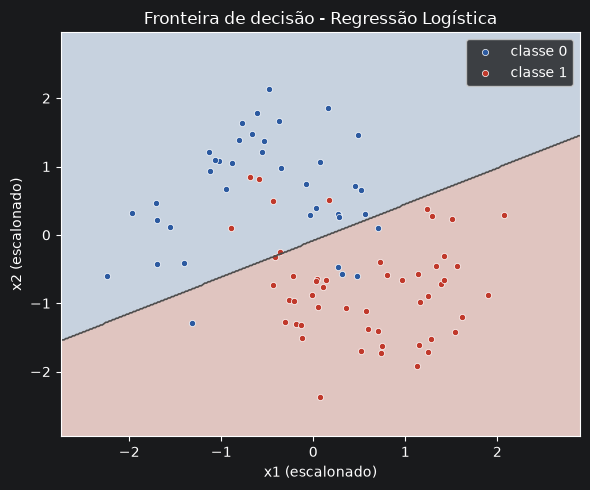

In [26]:
import matplotlib.pyplot as plt

# Malha de pontos cobrindo toda a area dos dados (treino + teste), para
# colorir cada regiao conforme a classe que o modelo preveria ali
X_plot = np.vstack([x_treino, x_teste])
xx, yy = np.meshgrid(
    np.linspace(X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5, 300),
    np.linspace(X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = logistica.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=["#dbe7f6", "#f7d9d3"], alpha=0.9)
ax.contour(xx, yy, Z, levels=[0.5], colors="#4c4c4c", linewidths=1.2)

cores_pontos = ["#2c5aa0", "#c0392b"]
for classe, cor in zip([0, 1], cores_pontos):
    pts = x_teste[y_teste == classe]
    ax.scatter(pts[:, 0], pts[:, 1], c=cor, s=20, edgecolors="white",
               linewidths=0.5, label=f"classe {classe}")

ax.set_title("Fronteira de decisão - Regressão Logística")
ax.set_xlabel("x1 (escalonado)")
ax.set_ylabel("x2 (escalonado)")
ax.legend()
fig.tight_layout()
plt.show()